# Model 1 - MLP Neural Network (Manual NumPy Implementation)
### DS4420 Group Project

---

**Research question:** what economic and structural factors determine a country’s share of renewable energy, and which countries are over or underperforming relative to what their profile would predict?

**This notebook:**
- Implements a two-hidden-layer MLP manually using NumPy only 
- Trains on a 2018 cross-section of 69 countries with complete data
- Evaluates generalization via 5-fold cross-validation 
- Identifies over- and under-performing countries via residual analysis

**Architecture:** `5 inputs → 64 (ReLU) → 32 (ReLU) → 1 (linear)`  
**Loss:** Mean Squared Error  
**Regularization:** L2 weight decay + early stopping per fold

---
## Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Reproducibility 
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data 
DATA_PATH = '../data/World_Energy_Consumption.csv'   # update path if needed
YEAR      = 2018   # last year with complete GDP data (confirmed in EDA notebook)

# Features (actual column names in OWID dataset) 
# Confirmed by EDA - these are the 5 interpretable economic/structural signals.
# We deliberately exclude any renewables-derived columns (e.g. renewables_share_elec)
# to avoid circularity: the model must learn from structural features, not from
# other ways of measuring the same thing.
FEATURES = [
    'gas_share_elec',            # gas share of electricity generation (r = -0.50)
    'fossil_elec_per_capita',    # fossil electricity per person (r = -0.42)
    'coal_share_energy',         # coal share of total energy (r = -0.28)
    'energy_per_gdp',            # energy intensity of economy (r = -0.19)
    'energy_per_capita',         # total energy use per person (r = +0.15)
]
TARGET = 'renewables_share_energy'

# Network architecture 
N_IN, H1, H2, N_OUT = len(FEATURES), 64, 32, 1

# Training hyperparameters
LR        = 0.005   # learning rate
MOMENTUM  = 0.9     # SGD momentum coefficient
LAMBDA_L2 = 0.01    # L2 regularization strength
MAX_EPOCHS = 3000
PATIENCE  = 300     # early stopping patience (epochs without improvement)
K_FOLDS   = 5       # number of cross-validation folds

print('Configuration loaded.')
print(f'Features : {FEATURES}')
print(f'Target   : {TARGET}')
print(f'Network  : {N_IN} → {H1} → {H2} → {N_OUT}')

Configuration loaded.
Features : ['gas_share_elec', 'fossil_elec_per_capita', 'coal_share_energy', 'energy_per_gdp', 'energy_per_capita']
Target   : renewables_share_energy
Network  : 5 → 64 → 32 → 1


---
## 1. Load and Filter Data

The OWID dataset contains regional aggregates (e.g. "Asia (Ember)", "World") alongside individual countries. We filter these out using `iso_code`: sovereign countries have 3-character ISO codes, while aggregates do not.

**Why 2018?** Our EDA notebook shows that `gdp` and `energy_per_gdp` are completely absent from 2019 onward in this dataset. 2018 is therefore the most recent year with a full feature set.

In [ ]:
df = pd.read_csv(DATA_PATH)

# Filter: single year, sovereign countries only (iso_code length == 3)
df_year = df[
    (df['year'] == YEAR) &
    df['iso_code'].notna() &
    (df['iso_code'].str.len() == 3)
].copy()

# Drop any row missing even one feature or the target
df_clean = (
    df_year[['country', 'iso_code'] + FEATURES + [TARGET]]
    .dropna()
    .reset_index(drop=True)
)

print(f'Sovereign countries in {YEAR}: {len(df_year)}')
print(f'Countries with complete data: {len(df_clean)}')
print(f'Dropped (any feature missing): {len(df_year) - len(df_clean)}')
print()
print('Target variable summary:')
display(df_clean[TARGET].describe().rename('renewables_share_energy (%)').to_frame().T.round(2))

Sovereign countries in 2018: 219
Countries with complete data: 69
Dropped (any feature missing): 150

Target variable summary:


,count,mean,std,min,25%,50%,75%,max
renewables_share_energy (%),69.0,14.36,13.1,0.01,5.75,9.42,20.76,69.6


---
## 2. Pre-processing

Neural networks are sensitive to feature scale, a feature with values in the billions (GDP) would dominate one with values from 0-100 (coal share) without normalization.

We apply two scaling steps:
- **Features (X):** Z-score standardization - subtract mean, divide by std. This centers each feature at 0 with unit variance.
- **Target (y):** Min-max scaling to [0, 1]. This prevents the output neuron from needing very large weights to match the raw scale.

Critically, normalization statistics are always computed **on the training fold only** during cross-validation, then applied to the validation fold - this prevents data leakage.

In [ ]:
# Extract raw arrays (normalization happens inside each CV fold)
X_raw = df_clean[FEATURES].values.astype(float)         # (69, 5)
y_raw = df_clean[TARGET].values.astype(float).reshape(-1, 1)  # (69, 1)

# Stratification tiers used for fold assignment so every fold covers the full range of the target (low → high renewable share)
bins   = [0, 5, 15, 30, 100]
labels = ['very_low', 'low', 'medium', 'high']
df_clean['tier'] = pd.cut(df_clean[TARGET], bins=bins, labels=labels)

tier_counts = df_clean['tier'].value_counts().sort_index()
print('Countries per tier:')
for tier, count in tier_counts.items():
    print(f'  {tier:<12}: {count}')
print()
print('Each fold will sample ~20% from each tier.')

Countries per tier:
  very_low    : 17
  low         : 27
  medium      : 18
  high        : 7

Each fold will sample ~20% from each tier.


---
## 3. Neural Network - Core Functions

We implement the MLP entirely from scratch. The key operations are:

**Forward pass:** Each layer computes $Z = XW + b$, then applies an activation. Hidden layers use ReLU ($\max(0, Z)$); the output layer is linear (no activation) since this is regression.

**Backward pass (backpropagation):** We apply the chain rule layer by layer to compute gradients of the MSE loss with respect to every weight and bias. The ReLU derivative is a binary mask: it passes gradients through where the pre-activation was positive, and blocks them where it was negative (the "dead neuron" region).

**He initialization:** Weights are drawn from $\mathcal{N}(0, \sqrt{2/\text{fan\_in}})$. This is specifically designed for ReLU activations and it keeps the variance of activations stable across layers, preventing vanishing or exploding gradients at the start of training.

In [ ]:
def init_weights(seed=None):
    """He initialization for all three weight matrices."""
    if seed is not None:
        np.random.seed(seed)
    W1 = np.random.randn(N_IN, H1) * np.sqrt(2.0 / N_IN)
    b1 = np.zeros((1, H1))
    W2 = np.random.randn(H1, H2)  * np.sqrt(2.0 / H1)
    b2 = np.zeros((1, H2))
    W3 = np.random.randn(H2, N_OUT) * np.sqrt(2.0 / H2)
    b3 = np.zeros((1, N_OUT))
    return W1, b1, W2, b2, W3, b3


def relu(Z):
    """Rectified Linear Unit activation: passes positive values, zeroes negative ones."""
    return np.maximum(0, Z)


def relu_deriv(Z):
    """Derivative of ReLU: 1 where Z > 0, 0 otherwise. Applied as a mask in backprop."""
    return (Z > 0).astype(float)


def forward(X, W1, b1, W2, b2, W3, b3):
    """
    Full forward pass through the network.
    Returns all intermediate pre-activations and activations which are needed during backpropagation.

    Shapes (N = batch size):
        Z1, A1 : (N, 64)
        Z2, A2 : (N, 32)
        Z3     : (N,  1)  raw prediction, no activation
    """
    Z1 = X  @ W1 + b1   # linear combination, layer 1
    A1 = relu(Z1)        # ReLU activation
    Z2 = A1 @ W2 + b2   # linear combination, layer 2
    A2 = relu(Z2)        # ReLU activation
    Z3 = A2 @ W3 + b3   # output layer linear (regression)
    return Z1, A1, Z2, A2, Z3


def backward(X, y, Z1, A1, Z2, A2, Z3, W2, W3):
    """
    Backpropagation computes gradients of MSE loss w.r.t. all weights and biases.
    Applies chain rule from output layer back to input layer.
    """
    N = len(y)

    # Output layer: dL/dZ3 = 2*(pred - true)/N  (derivative of MSE)
    dZ3 = 2 * (Z3 - y) / N          # (N,  1)
    dW3 = A2.T @ dZ3                 # (32, 1)  how much W3 contributed to loss
    db3 = dZ3.sum(axis=0, keepdims=True)

    # Hidden layer 2: chain rule back through W3, then ReLU gate
    dA2 = dZ3 @ W3.T                 # (N, 32)
    dZ2 = dA2 * relu_deriv(Z2)       # (N, 32) zero out gradient where neuron was off
    dW2 = A1.T @ dZ2                 # (64, 32)
    db2 = dZ2.sum(axis=0, keepdims=True)

    # Hidden layer 1: chain rule back through W2, then ReLU gate
    dA1 = dZ2 @ W2.T                 # (N, 64)
    dZ1 = dA1 * relu_deriv(Z1)       # (N, 64)
    dW1 = X.T @ dZ1                  # ( 5, 64)
    db1 = dZ1.sum(axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3


def mse(pred, true):
    return np.mean((pred - true) ** 2)


def r_squared(pred, true):
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot


print('Network functions defined.')
print(f'Architecture: {N_IN} → {H1}(ReLU) → {H2}(ReLU) → {N_OUT}(linear)')

Network functions defined.
Architecture: 5 → 64(ReLU) → 32(ReLU) → 1(linear)


---
## 4. Training Function

We use **SGD with momentum** rather than vanilla gradient descent. Momentum accumulates a velocity vector in directions of persistent gradient, which speeds up convergence and reduces oscillation.

The update rule for a weight $W$ is:
$$v \leftarrow \mu v - \alpha \nabla_W L \qquad W \leftarrow W + v$$
where $\mu = 0.9$ is the momentum coefficient and $\alpha$ is the learning rate.

**L2 regularization** adds a penalty proportional to the squared magnitude of weights to the loss: $L_{\text{total}} = L_{\text{MSE}} + \frac{\lambda}{2}\sum W^2$. This adds $\lambda W$ to each weight gradient, shrinking weights toward zero and discouraging the network from over-relying on any single input, which is crucial with only 69 training examples.

**Early stopping** monitors validation loss each epoch and halts training if it hasn't improved for `PATIENCE` epochs, then restores the weights from the best epoch.

In [ ]:
def train(X_tr, y_tr, X_val, y_val, seed=RANDOM_SEED, verbose=False):
    """
    Train the MLP on one train/validation split.

    Returns:
        best_weights : tuple of (W1,b1,W2,b2,W3,b3) from the epoch with lowest val loss
        train_losses : list of MSE per epoch (normalized scale)
        val_losses   : list of MSE per epoch (normalized scale)
        best_epoch   : epoch at which early stopping chose the weights
    """
    # Normalize (fit on training data only)
    X_mean = X_tr.mean(axis=0)
    X_std  = X_tr.std(axis=0) + 1e-8
    y_min  = y_tr.min()
    y_max  = y_tr.max()

    Xn_tr  = (X_tr  - X_mean) / X_std
    Xn_val = (X_val - X_mean) / X_std
    yn_tr  = (y_tr  - y_min)  / (y_max - y_min)
    yn_val = (y_val - y_min)  / (y_max - y_min)

    # Initialize weights
    W1, b1, W2, b2, W3, b3 = init_weights(seed)

    # Momentum velocity buffers
    vW1 = np.zeros_like(W1); vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2); vb2 = np.zeros_like(b2)
    vW3 = np.zeros_like(W3); vb3 = np.zeros_like(b3)

    train_losses, val_losses = [], []
    best_val_loss     = np.inf
    best_weights      = None
    best_epoch        = 0
    epochs_no_improve = 0

    for epoch in range(1, MAX_EPOCHS + 1):

        # Forward
        Z1, A1, Z2, A2, Z3 = forward(Xn_tr, W1, b1, W2, b2, W3, b3)
        loss_tr = mse(Z3, yn_tr)

        # Backward
        dW1, db1, dW2, db2, dW3, db3 = backward(
            Xn_tr, yn_tr, Z1, A1, Z2, A2, Z3, W2, W3
        )

        # L2 regularization gradients (biases are not regularized)
        dW1 += LAMBDA_L2 * W1
        dW2 += LAMBDA_L2 * W2
        dW3 += LAMBDA_L2 * W3

        # Momentum update
        vW1 = MOMENTUM * vW1 - LR * dW1;  W1 += vW1
        vb1 = MOMENTUM * vb1 - LR * db1;  b1 += vb1
        vW2 = MOMENTUM * vW2 - LR * dW2;  W2 += vW2
        vb2 = MOMENTUM * vb2 - LR * db2;  b2 += vb2
        vW3 = MOMENTUM * vW3 - LR * dW3;  W3 += vW3
        vb3 = MOMENTUM * vb3 - LR * db3;  b3 += vb3

        # Validation loss
        _, _, _, _, Z3_val = forward(Xn_val, W1, b1, W2, b2, W3, b3)
        loss_val = mse(Z3_val, yn_val)

        train_losses.append(loss_tr)
        val_losses.append(loss_val)

        # Early stopping
        if loss_val < best_val_loss:
            best_val_loss     = loss_val
            best_weights      = (W1.copy(), b1.copy(), W2.copy(),
                                 b2.copy(), W3.copy(), b3.copy())
            best_epoch        = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            break

        if verbose and (epoch % 500 == 0 or epoch == 1):
            print(f'  Epoch {epoch:4d} | Train MSE: {loss_tr:.5f} | Val MSE: {loss_val:.5f}')

    # Store normalization params inside weights tuple for later prediction
    norm_params = (X_mean, X_std, y_min, y_max)
    return best_weights, norm_params, train_losses, val_losses, best_epoch


def predict(X, weights, norm_params):
    """Predict in original percentage units (0–100) given raw X."""
    X_mean, X_std, y_min, y_max = norm_params
    W1, b1, W2, b2, W3, b3 = weights
    Xn = (X - X_mean) / X_std
    _, _, _, _, Z3 = forward(Xn, W1, b1, W2, b2, W3, b3)
    return Z3 * (y_max - y_min) + y_min   # undo min-max scaling


print('Training function defined.')

Training function defined.


---
## 5. Stratified K-Fold Cross-Validation

With only 69 countries, a single 80/20 train-test split gives a test set of about 13 countries. That is too small to produce reliable metrics, a single outlier country (e.g. Norway or Brazil) can shift test RMSE by several percentage points.

**K-fold cross-validation** solves this by rotating through the data: we split the 69 countries into 5 folds of about 14 countries each, train on 4 folds (55 countries), evaluate on the held-out fold, and repeat 5 times. Every country appears in the test set exactly once.

**Stratified** means each fold is sampled proportionally from each renewables tier (very low / low / medium / high), so no fold is accidentally all high-renewables or all low-renewables countries.

We report mean ± std across folds, so that means both numbers matter. A low mean with low std means the model generalizes consistently. A low mean with high std means performance is sensitive to which countries end up in the test set.

In [ ]:
# Build stratified fold assignments
# Within each tier, shuffle indices and assign fold numbers 0..K-1 cyclically.
np.random.seed(RANDOM_SEED)
fold_assignments = np.full(len(df_clean), -1, dtype=int)

for tier_label in df_clean['tier'].cat.categories:
    tier_idx = df_clean.index[df_clean['tier'] == tier_label].tolist()
    np.random.shuffle(tier_idx)
    for i, idx in enumerate(tier_idx):
        fold_assignments[idx] = i % K_FOLDS

df_clean['fold'] = fold_assignments

print(f'Fold assignments ({K_FOLDS} folds, stratified by renewables tier):')
print(pd.crosstab(df_clean['tier'], df_clean['fold'],
                  margins=True, margins_name='Total').rename_axis('tier'))

Fold assignments (5 folds, stratified by renewables tier):
fold       0   1   2   3   4  Total
tier                               
very_low   4   4   3   3   3     17
low        6   6   5   5   5     27
medium     4   4   4   3   3     18
high       2   2   1   1   1      7
Total     16  16  13  12  12     69


In [ ]:
# Run K-fold cross-validation 
fold_results   = []   # metrics per fold
all_val_losses = []   # learning curves per fold (for plotting)
all_tr_losses  = []
oof_preds      = np.full(len(df_clean), np.nan)  # out-of-fold predictions

print(f'Running {K_FOLDS}-fold cross-validation...\n')
print(f'{"Fold":<6} {"Val RMSE (pp)":<16} {"Val R²":<12} {"Best Epoch"}')
print('-' * 46)

for fold in range(K_FOLDS):
    val_mask  = df_clean['fold'] == fold
    train_mask = ~val_mask

    X_tr  = X_raw[train_mask]
    y_tr  = y_raw[train_mask]
    X_val = X_raw[val_mask]
    y_val = y_raw[val_mask]

    # Train (each fold gets a different seed so weight init varies)
    weights, norm_params, tr_losses, val_losses, best_ep = train(
        X_tr, y_tr, X_val, y_val, seed=RANDOM_SEED + fold
    )

    # Predict on held-out fold in original units
    y_pred = predict(X_val, weights, norm_params).flatten()
    y_true = y_val.flatten()

    fold_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    fold_r2   = r_squared(y_pred.reshape(-1,1), y_true.reshape(-1,1))

    fold_results.append({
        'fold': fold + 1,
        'rmse': fold_rmse,
        'r2':   fold_r2,
        'best_epoch': best_ep,
        'weights': weights,
        'norm_params': norm_params,
    })
    all_val_losses.append(val_losses)
    all_tr_losses.append(tr_losses)

    # Store out-of-fold predictions
    val_indices = df_clean.index[val_mask].tolist()
    for i, idx in enumerate(val_indices):
        oof_preds[idx] = y_pred[i]

    print(f'{fold+1:<6} {fold_rmse:<16.3f} {fold_r2:<12.4f} {best_ep}')

# Summary statistics
rmse_scores = [r['rmse'] for r in fold_results]
r2_scores   = [r['r2']   for r in fold_results]

print('-' * 46)
print(f'{"Mean":<6} {np.mean(rmse_scores):<16.3f} {np.mean(r2_scores):<12.4f}')
print(f'{"Std":<6} {np.std(rmse_scores):<16.3f} {np.std(r2_scores):<12.4f}')
print()
print(f'Cross-validated RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f} percentage points')
print(f'Cross-validated R²  : {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}')

Running 5-fold cross-validation...

Fold   Val RMSE (pp)    Val R²       Best Epoch
----------------------------------------------
1      8.271            0.7629       23
2      11.453           -0.1467      30
3      11.038           0.2995       3000
4      9.361            0.3084       3000
5      5.048            0.7805       2918
----------------------------------------------
Mean   9.034            0.4009      
Std    2.300            0.3446      

Cross-validated RMSE: 9.03 ± 2.30 percentage points
Cross-validated R²  : 0.401 ± 0.345


---
## 6. Learning Curves

Plotting train and validation loss per epoch lets us check whether the model is overfitting. We show all 5 folds overlaid, if the curves look similar across folds, the model is training consistently regardless of which countries it sees.

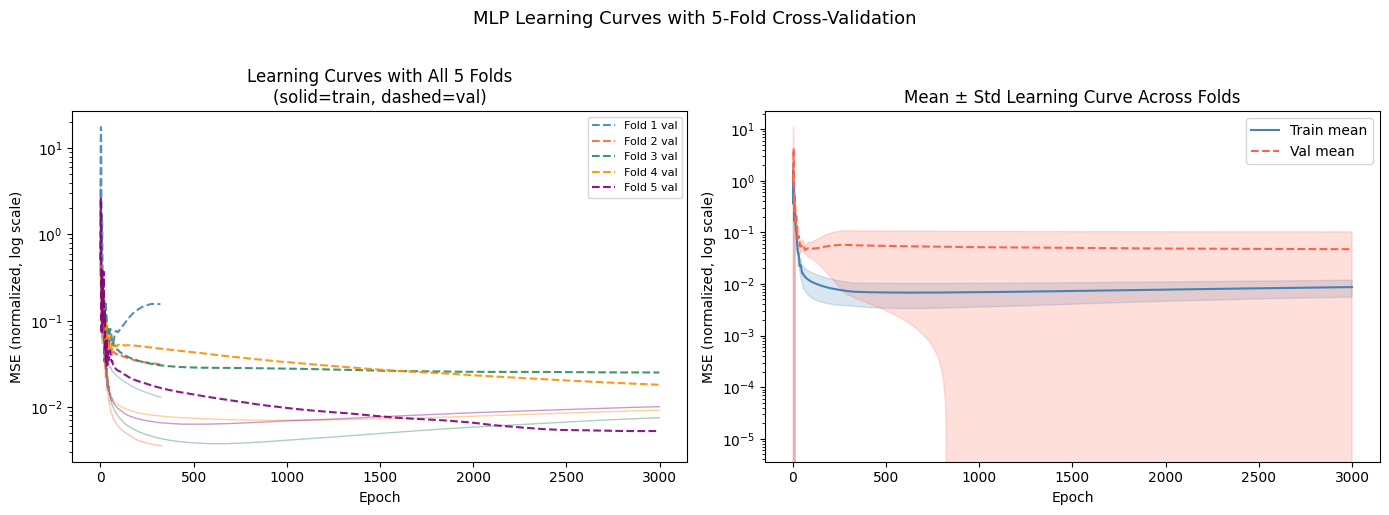

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple']

# Left: all 5 fold learning curves
ax = axes[0]
for fold_i, (tr, val) in enumerate(zip(all_tr_losses, all_val_losses)):
    ax.plot(tr,  color=colors[fold_i], alpha=0.4, linewidth=1)
    ax.plot(val, color=colors[fold_i], alpha=0.9, linewidth=1.5,
            linestyle='--', label=f'Fold {fold_i+1} val')

ax.set_yscale('log')
ax.set_title('Learning Curves with All 5 Folds\n(solid=train, dashed=val)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (normalized, log scale)')
ax.legend(fontsize=8)

# Right: mean ± std band
ax = axes[1]
max_len = max(len(v) for v in all_val_losses)

# Pad shorter curves with their last value so we can stack them
def pad(curves, length):
    return np.array([c + [c[-1]] * (length - len(c)) for c in curves])

tr_mat  = pad(all_tr_losses,  max_len)
val_mat = pad(all_val_losses, max_len)

epochs_x = np.arange(1, max_len + 1)
ax.plot(epochs_x, tr_mat.mean(0),  color='steelblue', label='Train mean')
ax.fill_between(epochs_x,
    tr_mat.mean(0) - tr_mat.std(0),
    tr_mat.mean(0) + tr_mat.std(0),
    alpha=0.2, color='steelblue')

ax.plot(epochs_x, val_mat.mean(0), color='tomato', linestyle='--', label='Val mean')
ax.fill_between(epochs_x,
    val_mat.mean(0) - val_mat.std(0),
    val_mat.mean(0) + val_mat.std(0),
    alpha=0.2, color='tomato')

ax.set_yscale('log')
ax.set_title('Mean ± Std Learning Curve Across Folds')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (normalized, log scale)')
ax.legend()

plt.suptitle('MLP Learning Curves with 5-Fold Cross-Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

- The model is overfitting despite L2 and early stopping. With n = 69, the network has enough capacity (64 → 32 hidden units) to memorize patterns in 55 training countries that don't generalize to the remaining 14. 
- The learning curves actually justify the methodological choices, they show exactly why a single train-test split would have been unreliable, and why early stopping was necessary even if it didn't fully close the gap

---
## 7. Final Model - Train on All 69 Countries

Cross-validation gave us an honest estimate of generalization error. Now we train a final model on **all 69 countries** to get the best possible residual estimates for every country, this is the main scientific output of Model 1.

We use the mean best epoch across folds as the target number of training epochs, which avoids the need for a held-out set while still preventing overtraining.

In [ ]:
# Normalize on all 69 countries 
X_mean_final = X_raw.mean(axis=0)
X_std_final  = X_raw.std(axis=0) + 1e-8
y_min_final  = y_raw.min()
y_max_final  = y_raw.max()

Xn_all = (X_raw - X_mean_final) / X_std_final
yn_all = (y_raw - y_min_final)  / (y_max_final - y_min_final)

# Initialize & train
# Target epochs = mean best epoch across folds (avoids needing a held-out set)
target_epochs = int(np.mean([r['best_epoch'] for r in fold_results]))
print(f'Training final model for {target_epochs} epochs (mean best epoch across folds)...')

np.random.seed(RANDOM_SEED)
W1f, b1f, W2f, b2f, W3f, b3f = init_weights(RANDOM_SEED)
vW1 = np.zeros_like(W1f); vb1 = np.zeros_like(b1f)
vW2 = np.zeros_like(W2f); vb2 = np.zeros_like(b2f)
vW3 = np.zeros_like(W3f); vb3 = np.zeros_like(b3f)

final_losses = []

for epoch in range(1, target_epochs + 1):
    Z1, A1, Z2, A2, Z3 = forward(Xn_all, W1f, b1f, W2f, b2f, W3f, b3f)
    loss = mse(Z3, yn_all)
    final_losses.append(loss)

    dW1, db1, dW2, db2, dW3, db3 = backward(
        Xn_all, yn_all, Z1, A1, Z2, A2, Z3, W2f, W3f
    )
    dW1 += LAMBDA_L2 * W1f
    dW2 += LAMBDA_L2 * W2f
    dW3 += LAMBDA_L2 * W3f

    vW1 = MOMENTUM * vW1 - LR * dW1;  W1f += vW1
    vb1 = MOMENTUM * vb1 - LR * db1;  b1f += vb1
    vW2 = MOMENTUM * vW2 - LR * dW2;  W2f += vW2
    vb2 = MOMENTUM * vb2 - LR * db2;  b2f += vb2
    vW3 = MOMENTUM * vW3 - LR * dW3;  W3f += vW3
    vb3 = MOMENTUM * vb3 - LR * db3;  b3f += vb3

final_weights     = (W1f, b1f, W2f, b2f, W3f, b3f)
final_norm_params = (X_mean_final, X_std_final, y_min_final, y_max_final)

print(f'Final training loss: {final_losses[-1]:.5f}')

Training final model for 1794 epochs (mean best epoch across folds)...
Final training loss: 0.00755


---
## 8. Residual Analysis - Which Countries Surprise the Model?

The residual for each country is:
$$\text{residual} = \text{actual renewables share} - \text{predicted renewables share}$$

A **positive residual** means the country has *more* renewables than its economic profile predicts, it is an over-performer. These are often countries with large natural hydro resources, strong climate policy, or geographic advantages not captured by the features.

A **negative residual** means the country has *less* renewables than predicted, an under-performer. These are often fossil-fuel exporters or countries where policy has slowed the transition despite structural conditions that would otherwise favour renewables.

We use the out-of-fold (OOF) predictions for this analysis where possible, since OOF predictions for each country were made by a model that had **never seen that country during training** They are the most honest per-country estimates we have.

In [ ]:
# Out-of-fold residuals (most honest per-country estimates)
y_true_all = y_raw.flatten()

df_results = df_clean[['country', 'iso_code', TARGET, 'tier']].copy()
df_results['oof_predicted'] = oof_preds
df_results['oof_residual']  = y_true_all - oof_preds
df_results['abs_residual']  = np.abs(df_results['oof_residual'])

# Also add final-model predictions for reference
final_preds = predict(X_raw, final_weights, final_norm_params).flatten()
df_results['final_predicted'] = final_preds
df_results['final_residual']  = y_true_all - final_preds

df_results = df_results.sort_values('oof_residual', ascending=False).reset_index(drop=True)

print('TOP 10 OVER-PERFORMERS (actual >> predicted)')
print('Countries where renewables adoption exceeds what economic profile predicts')
print()
top10 = df_results.head(10)[['country', TARGET, 'oof_predicted', 'oof_residual']].copy()
top10.columns = ['Country', 'Actual (%)', 'Predicted (%)', 'Residual (pp)']
display(top10.round(2).reset_index(drop=True))

print()
print('TOP 10 UNDER-PERFORMERS (actual << predicted)')
print('Countries where renewables adoption lags behind what economic profile predicts')
print()
bot10 = df_results.tail(10)[['country', TARGET, 'oof_predicted', 'oof_residual']].copy()
bot10.columns = ['Country', 'Actual (%)', 'Predicted (%)', 'Residual (pp)']
display(bot10.round(2).reset_index(drop=True))

TOP 10 OVER-PERFORMERS (actual >> predicted)
Countries where renewables adoption exceeds what economic profile predicts



,Country,Actual (%),Predicted (%),Residual (pp)
0,Brazil,45.43,21.57,23.86
1,New Zealand,38.04,22.58,15.45
2,Norway,69.60,54.95,14.65
3,Germany,17.14,3.21,13.92
4,Chile,24.33,10.61,13.73
5,Latvia,23.44,11.47,11.98
6,Peru,29.43,17.56,11.87
7,Portugal,26.88,15.73,11.15
8,Austria,34.53,23.59,10.94
9,North Macedonia,17.79,8.25,9.54



TOP 10 UNDER-PERFORMERS (actual << predicted)
Countries where renewables adoption lags behind what economic profile predicts



,Country,Actual (%),Predicted (%),Residual (pp)
0,Ecuador,27.49,35.69,-8.21
1,Slovakia,9.38,19.28,-9.90
2,Uzbekistan,2.93,12.96,-10.03
3,Hong Kong,0.12,11.82,-11.70
4,Canada,28.89,41.71,-12.81
5,Luxembourg,7.14,24.11,-16.96
6,France,11.96,30.83,-18.87
7,Ukraine,3.46,24.02,-20.56
8,Poland,5.85,30.94,-25.08
9,Morocco,7.10,35.27,-28.17


---
## 9. Results Visualization

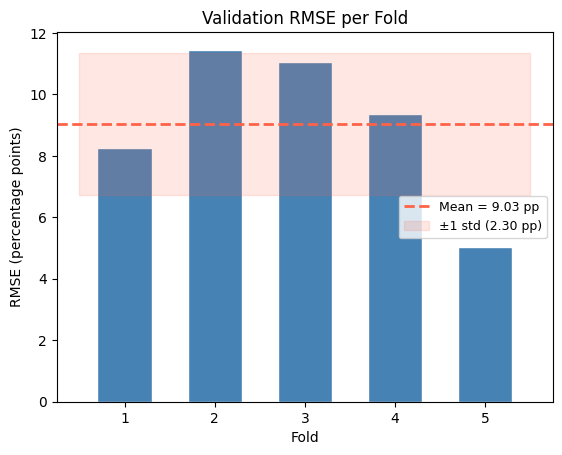

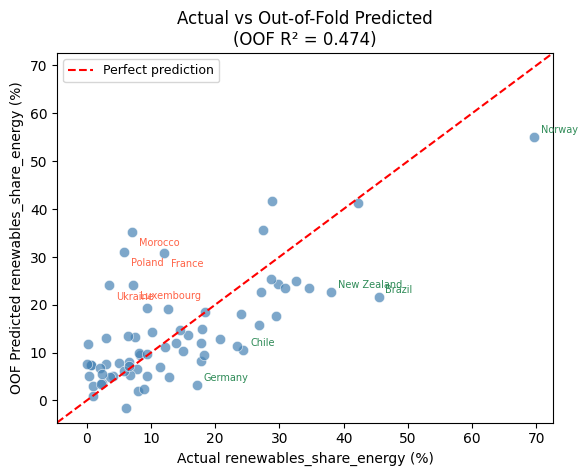

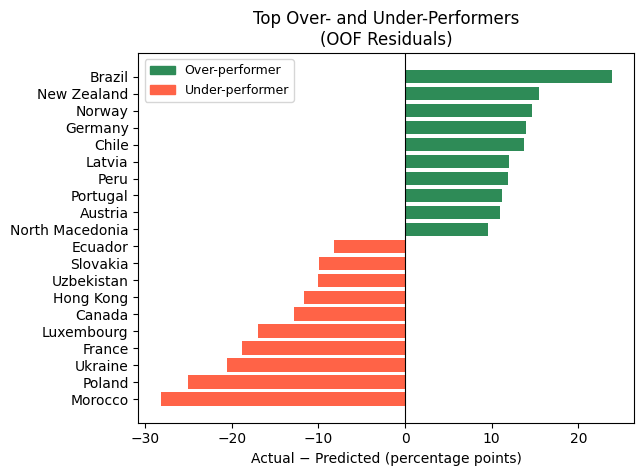

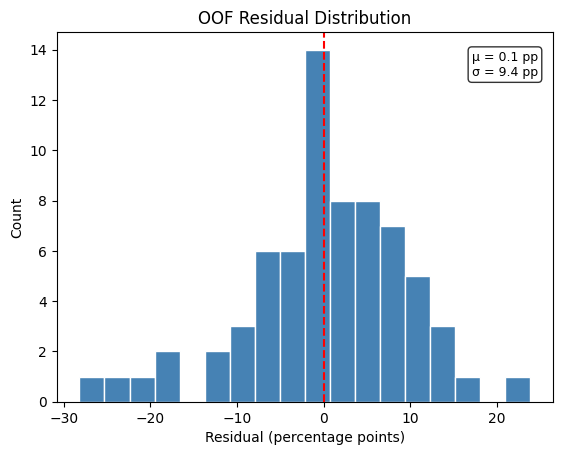

In [ ]:
# Separate each plot into its own figure for better readability and so they can be saved individually if desired
# 9a. CV RMSE per fold
plt.figure()
fold_nums = [r['fold'] for r in fold_results]
plt.bar(fold_nums, rmse_scores, color='steelblue', edgecolor='white', width=0.6)
plt.axhline(np.mean(rmse_scores), color='tomato', linewidth=2, linestyle='--',
           label=f'Mean = {np.mean(rmse_scores):.2f} pp')
plt.fill_between([0.5, K_FOLDS + 0.5],
    np.mean(rmse_scores) - np.std(rmse_scores),
    np.mean(rmse_scores) + np.std(rmse_scores),
    alpha=0.15, color='tomato', label=f'±1 std ({np.std(rmse_scores):.2f} pp)')
plt.title('Validation RMSE per Fold')
plt.xlabel('Fold')
plt.ylabel('RMSE (percentage points)')
plt.xticks(fold_nums)
plt.legend(fontsize=9)
plt.show()
 
# 9b. Actual vs OOF-Predicted (all countries)
plt.figure()
plt.scatter(y_true_all, oof_preds, alpha=0.7, color='steelblue',
           s=55, edgecolors='white', linewidths=0.5)
lim_min = min(y_true_all.min(), np.nanmin(oof_preds)) - 3
lim_max = max(y_true_all.max(), np.nanmax(oof_preds)) + 3
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5,
        label='Perfect prediction')
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)
oof_r2 = r_squared(oof_preds.reshape(-1,1), y_true_all.reshape(-1,1))
plt.title(f'Actual vs Out-of-Fold Predicted\n(OOF R² = {oof_r2:.3f})')
plt.xlabel('Actual renewables_share_energy (%)')
plt.ylabel('OOF Predicted renewables_share_energy (%)')
plt.legend(fontsize=9)
 
# Annotate top outliers
for _, row in df_results.head(5).iterrows():
    plt.annotate(row['country'], (row[TARGET], row['oof_predicted']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7, color='seagreen')
for _, row in df_results.tail(5).iterrows():
    plt.annotate(row['country'], (row[TARGET], row['oof_predicted']),
                textcoords='offset points', xytext=(5, -10),
                fontsize=7, color='tomato')
plt.show()
 
# 9c. Residual bar chart (top/bottom 10)
plt.figure()
top10_bar = df_results.head(10).copy()
bot10_bar = df_results.tail(10).copy()
combined  = pd.concat([top10_bar, bot10_bar]).sort_values('oof_residual')
bar_colors = ['seagreen' if r > 0 else 'tomato' for r in combined['oof_residual']]
plt.barh(combined['country'], combined['oof_residual'], color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Over- and Under-Performers\n(OOF Residuals)')
plt.xlabel('Actual − Predicted (percentage points)')
over_patch  = mpatches.Patch(color='seagreen', label='Over-performer')
under_patch = mpatches.Patch(color='tomato',   label='Under-performer')
plt.legend(handles=[over_patch, under_patch], fontsize=9)
plt.show()
 
# 9d. Residual distribution
plt.figure()
oof_residuals = df_results['oof_residual'].values
plt.hist(oof_residuals, bins=18, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--')
mu, sigma = np.nanmean(oof_residuals), np.nanstd(oof_residuals)
plt.title('OOF Residual Distribution')
plt.xlabel('Residual (percentage points)')
plt.ylabel('Count')
plt.text(0.97, 0.95, f'μ = {mu:.1f} pp\nσ = {sigma:.1f} pp',
        transform=plt.gca().transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
plt.show()

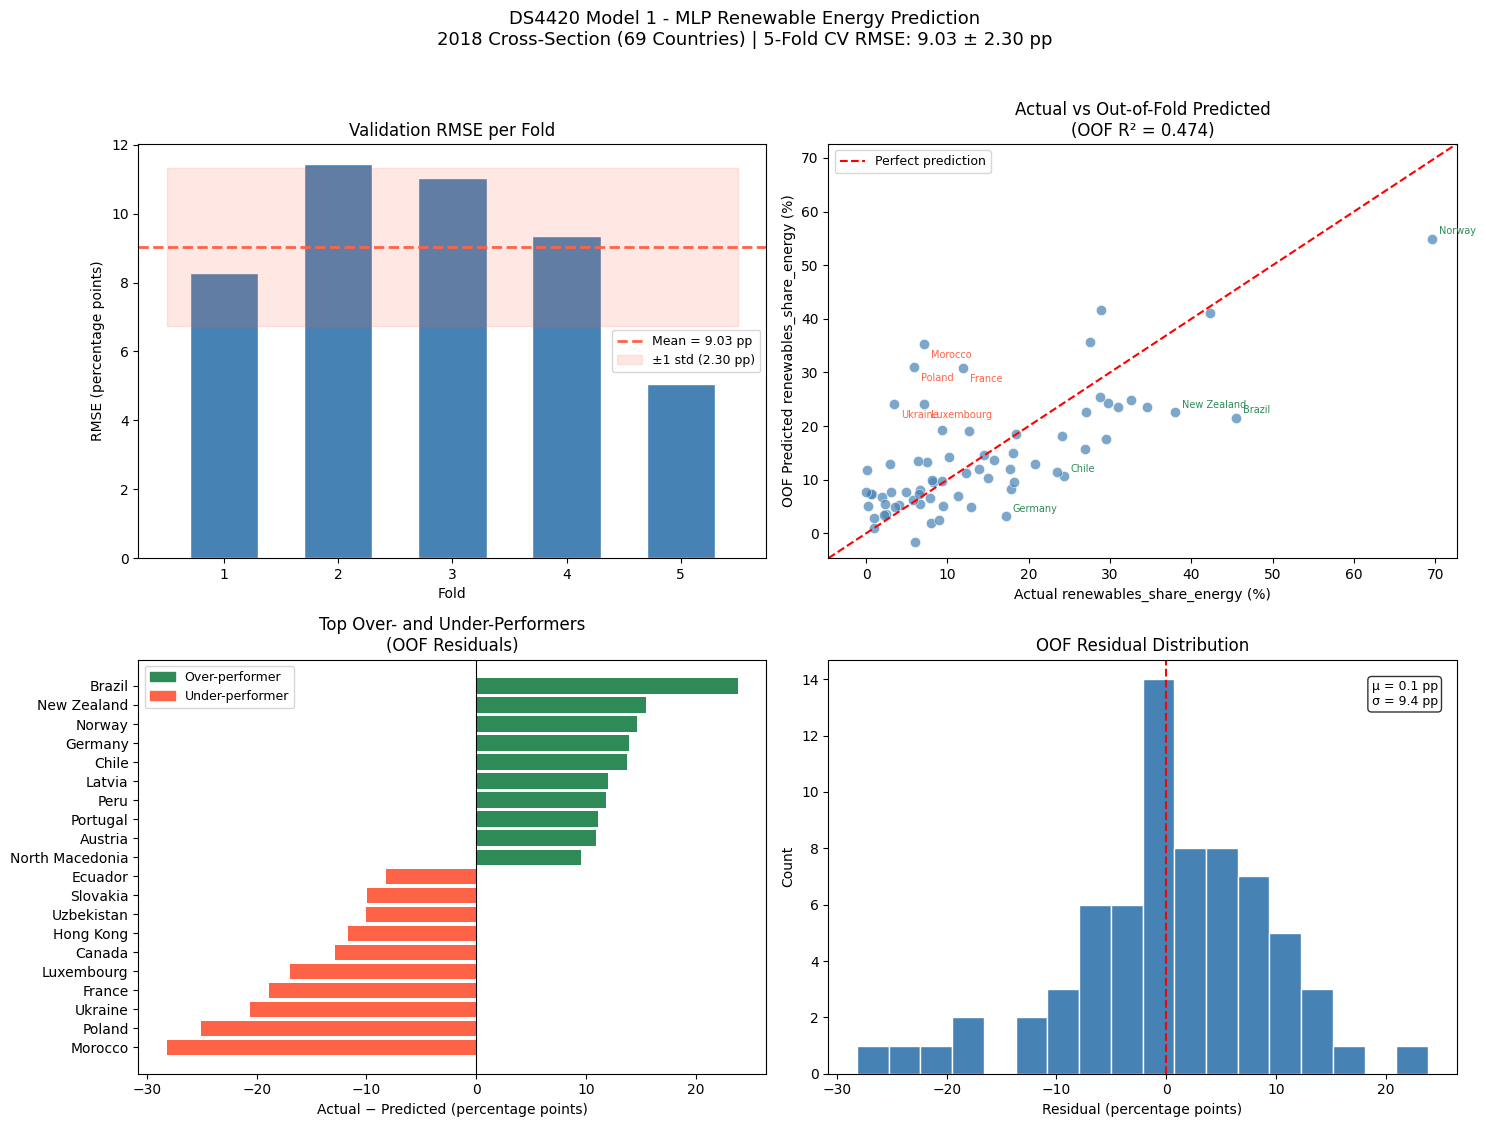

In [ ]:
# Combined plot with all 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    'DS4420 Model 1 - MLP Renewable Energy Prediction\n'
    f'2018 Cross-Section ({len(df_clean)} Countries) | 5-Fold CV RMSE: '
    f'{np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f} pp',
    fontsize=13, y=1.02
    )
 
# 9a. CV RMSE per fold
ax = axes[0, 0]
fold_nums = [r['fold'] for r in fold_results]
ax.bar(fold_nums, rmse_scores, color='steelblue', edgecolor='white', width=0.6)
ax.axhline(np.mean(rmse_scores), color='tomato', linewidth=2, linestyle='--',
           label=f'Mean = {np.mean(rmse_scores):.2f} pp')
ax.fill_between([0.5, K_FOLDS + 0.5],
    np.mean(rmse_scores) - np.std(rmse_scores),
    np.mean(rmse_scores) + np.std(rmse_scores),
    alpha=0.15, color='tomato', label=f'±1 std ({np.std(rmse_scores):.2f} pp)')
ax.set_title('Validation RMSE per Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE (percentage points)')
ax.set_xticks(fold_nums)
ax.legend(fontsize=9)
 
# 9b. Actual vs OOF-Predicted (all countries) 
ax = axes[0, 1]
ax.scatter(y_true_all, oof_preds, alpha=0.7, color='steelblue',
           s=55, edgecolors='white', linewidths=0.5)
lim_min = min(y_true_all.min(), np.nanmin(oof_preds)) - 3
lim_max = max(y_true_all.max(), np.nanmax(oof_preds)) + 3
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5,
        label='Perfect prediction')
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
oof_r2 = r_squared(oof_preds.reshape(-1,1), y_true_all.reshape(-1,1))
ax.set_title(f'Actual vs Out-of-Fold Predicted\n(OOF R² = {oof_r2:.3f})')
ax.set_xlabel('Actual renewables_share_energy (%)')
ax.set_ylabel('OOF Predicted renewables_share_energy (%)')
ax.legend(fontsize=9)
 
# Annotate top outliers
for _, row in df_results.head(5).iterrows():
    ax.annotate(row['country'], (row[TARGET], row['oof_predicted']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7, color='seagreen')
for _, row in df_results.tail(5).iterrows():
    ax.annotate(row['country'], (row[TARGET], row['oof_predicted']),
                textcoords='offset points', xytext=(5, -10),
                fontsize=7, color='tomato')
 
# 9c. Residual bar chart (top/bottom 10)
ax = axes[1, 0]
top10_bar = df_results.head(10).copy()
bot10_bar = df_results.tail(10).copy()
combined  = pd.concat([top10_bar, bot10_bar]).sort_values('oof_residual')
bar_colors = ['seagreen' if r > 0 else 'tomato' for r in combined['oof_residual']]
ax.barh(combined['country'], combined['oof_residual'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top Over- and Under-Performers\n(OOF Residuals)')
ax.set_xlabel('Actual − Predicted (percentage points)')
over_patch  = mpatches.Patch(color='seagreen', label='Over-performer')
under_patch = mpatches.Patch(color='tomato',   label='Under-performer')
ax.legend(handles=[over_patch, under_patch], fontsize=9)
 
# 9d. Residual distribution
ax = axes[1, 1]
oof_residuals = df_results['oof_residual'].values
ax.hist(oof_residuals, bins=18, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
mu, sigma = np.nanmean(oof_residuals), np.nanstd(oof_residuals)
ax.set_title('OOF Residual Distribution')
ax.set_xlabel('Residual (percentage points)')
ax.set_ylabel('Count')
ax.text(0.97, 0.95, f'μ = {mu:.1f} pp\nσ = {sigma:.1f} pp',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
 
plt.tight_layout()
plt.savefig('mlp_results_combined.png', dpi=150, bbox_inches='tight')
plt.show()
 

---
## 10. Summary & Interpretation

This cell prints a clean summary table suitable for inclusion in the report.

In [ ]:
print('=' * 60)
print('MODEL 1 - MLP RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset          : OWID World Energy Consumption')
print(f'Year             : {YEAR} (last year with complete GDP data)')
print(f'Countries (n)    : {len(df_clean)}')
print(f'Features (p)     : {len(FEATURES)}')
print(f'Architecture     : {N_IN} → {H1}(ReLU) → {H2}(ReLU) → {N_OUT}(linear)')
print(f'Regularization   : L2 (λ={LAMBDA_L2}) + early stopping (patience={PATIENCE})')
print(f'Optimizer        : SGD + momentum (lr={LR}, μ={MOMENTUM})')
print()
print(f'Evaluation       : Stratified {K_FOLDS}-fold cross-validation')
print(f'CV RMSE          : {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f} percentage points')
print(f'CV R²            : {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}')
print(f'OOF R²           : {oof_r2:.3f}  (full-dataset out-of-fold)')
print()
print('Key outliers (OOF residuals):')
print(f'  Top over-performer  : {df_results.iloc[0]["country"]} '
      f'(+{df_results.iloc[0]["oof_residual"]:.1f} pp)')
print(f'  Top under-performer : {df_results.iloc[-1]["country"]} '
      f'({df_results.iloc[-1]["oof_residual"]:.1f} pp)')
print('=' * 60)

# Save full results table
output_cols = ['country', 'iso_code', TARGET, 'oof_predicted', 'oof_residual',
               'final_predicted', 'final_residual', 'abs_residual', 'tier']
df_results[output_cols].round(3).to_csv('mlp_country_predictions.csv', index=False)
print('\nFull country-level results saved to mlp_country_predictions.csv')

MODEL 1 - MLP RESULTS SUMMARY
Dataset          : OWID World Energy Consumption
Year             : 2018 (last year with complete GDP data)
Countries (n)    : 69
Features (p)     : 5
Architecture     : 5 → 64(ReLU) → 32(ReLU) → 1(linear)
Regularization   : L2 (λ=0.01) + early stopping (patience=300)
Optimizer        : SGD + momentum (lr=0.005, μ=0.9)

Evaluation       : Stratified 5-fold cross-validation
CV RMSE          : 9.03 ± 2.30 percentage points
CV R²            : 0.401 ± 0.345
OOF R²           : 0.474  (full-dataset out-of-fold)

Key outliers (OOF residuals):
  Top over-performer  : Brazil (+23.9 pp)
  Top under-performer : Morocco (-28.2 pp)

Full country-level results saved to mlp_country_predictions.csv
